In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

## 1. Basic Kalman filter implementation

Consider the dynamical system
$$\begin{align}
    x_{t+1} {}={} & A x_t + G w_t,
    \\
    y_t {}={}     & C x_t + v_t.
\end{align}$$
where $A$, $G$, and $C$ are given below


In [2]:
A = np.array([[0.9, 0.15], [-0.15, 0.9]])
G = np.array([[1.2, 0.9], [0, 1]])
C = np.array([[1, 0]])

the variance-covariance matrices of $w$ and $v$ are



In [3]:
Q = np.array([[0.05, 0.002], [0.002, 0.05]])
R = 0.08

and all assumptions of the Gauss-Markov model are satisfied.

Implement the Kalman filter and plot the actual state, $x_t$, and estimated states $\hat{x}_{t\mid t}$, for $t=0,1,\ldots, T$ (up to a sufficiently large time $T$)

In [ ]:
def measurement_update(sigma, x_estimate, y):
    x_update = x_estimate + sigma @ C.T @ np.linalg.solve(C @ sigma @ C.T + R, y - C @ x_estimate)
    sigma_update = sigma - sigma @ C.T @ np.linalg.solve(C @ sigma @ C.T + R, C @ sigma)
    return x_update, sigma_update

def time_update(sigma, x_estimate):
    x_new = A @ x_estimate
    sigma_new = A @ sigma @ A.T + G @ Q @ G.T
    return x_new, sigma_new

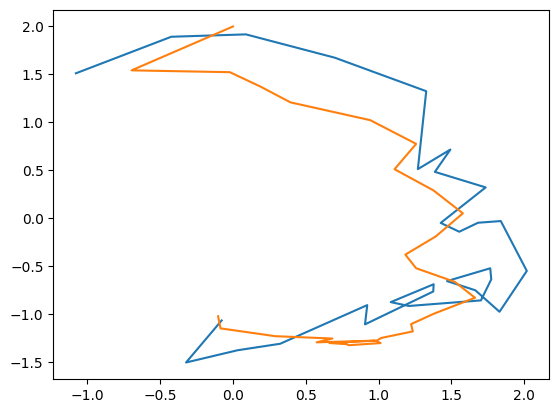

In [92]:
np.random.seed(67)
x0_mean = np.array([0, 2])
x0_var = np.array([[0.9, 0.4], [0.4, 0.3]])
N = 30

x_0 = np.random.multivariate_normal(x0_mean, x0_var)

x_t = np.zeros((2, N))
y_t = np.zeros((1, N))
x_estimate = np.zeros((2, N))

sigma = x0_var 

x_t = np.zeros((2, N))
x_t[:, 0] = x_0
x_estimate[:, 0] = x0_mean

for t in range(N - 1):

    w = np.random.multivariate_normal(np.array([0, 0]), Q)
    v = np.random.normal(0, np.sqrt(R))

    y_t[:, t] = C @ x_t[:, t] + v

    x_update, sigma = measurement_update(sigma, x_estimate[:, t], y_t[:, t])

    x_estimate[:, t + 1], sigma = time_update(sigma, x_update)
    
    # True state.
    x_t[:, t + 1] = A @ x_t[:, t] + G @ w




plt.plot(x_t[0, :], x_t[1, :])
plt.plot(x_estimate[0, :], x_estimate[1, :])
plt.show()


## 2. Kalman filter design

Consider a dynamical system with state $x_t\in{\rm I\!R}^3$ with 
$$x_{t+1} = \begin{bmatrix}0.7 & 0.1 & -0.1 \\ 0.2 & 0.6 & 1 \\ 1 & 0.1 & 0.1\end{bmatrix}x_t + \begin{bmatrix}d_t \\ 0 \\ 0\end{bmatrix} + w_t,$$
where $d_t$ is an unknown bias, and $w_t\sim \mathcal{N}(0, Q)$ is an iid process noise with covariance matrix 
$$Q = \begin{bmatrix}0.1 & 0.01 & 0\\0.01 & 0.05 & 0\\0 & 0 & 0.05\end{bmatrix}.$$
The system is equipped with two sensors for measuring the first coordinate of the state, each with an additive iid measurement noise with covariance $\sigma_1^2=\sigma_2^2=0.012$. A third sensor is used to measure $x_2 + x_3$ with additive iid measurement noise $\sigma_3^2=0.022$, that is,
$$y_{3,t} = x_{2,t} + x_{3,t} + v_{3,t},$$
where $x_{2,t}$ and $x_{3, t}$ are the second and third coordinates of the state vector, and $v_{3, t} \sim \mathcal{N}(0, \sigma_3^2)$. A fourth sensor is used to measure the difference $x_2 - x_3$ with additive iid measurement noise $\sigma_4^2=0.019$. The measurement noises $v_1, v_2, v_3, v_4$ are independent from one another.

**Your task:** implement a Kalman filter for this system and show plots similar to the ones

In [11]:
# Your code goes here